In [1]:
# Sari zaroori libraries import karo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # warnings band karo

# Stats models se ARIMA/SARIMA/SARIMAX import karo
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Testing ke liye
from statsmodels.tsa.stattools import adfuller  # Stationarity test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # ACF/PACF plots
from statsmodels.stats.diagnostic import acorr_ljungbox  # Residual test

from sklearn.metrics import mean_absolute_error, mean_squared_error  # Accuracy metrics

print("Sari libraries successfully import ho gayi!")

Sari libraries successfully import ho gayi!


In [2]:
# Hum yahan AirPassengers dataset use karenge (built-in classic dataset)
# Isme monthly airline passengers ka data hai 1949-1960

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)

# Column ka naam simple rakh lo
df.columns = ['Passengers']

# Frequency set karo - yahan monthly data hai
df.index.freq = 'MS'  # MS = Month Start

print("Data shape:", df.shape)
print("\nPehli 5 rows:")
print(df.head())
print("\nAakhri 5 rows:")
print(df.tail())

Data shape: (144, 1)

Pehli 5 rows:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Aakhri 5 rows:
            Passengers
Month                 
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432


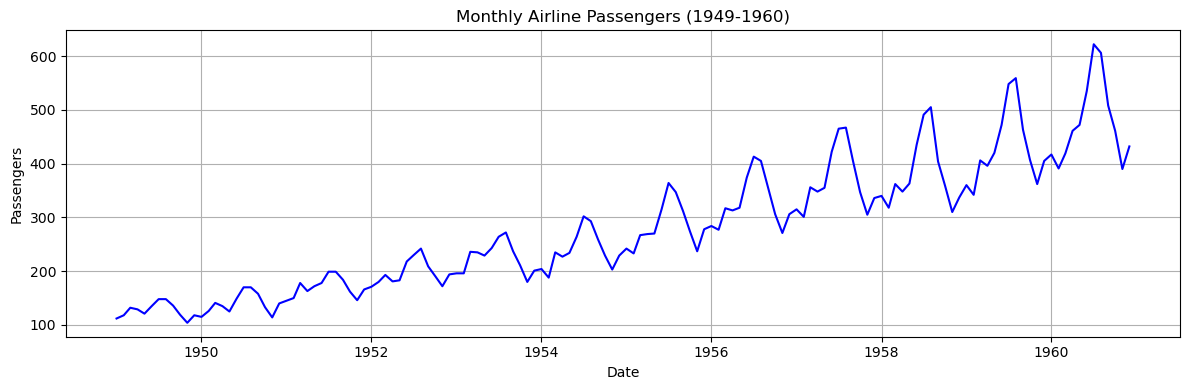

Data dekho: Trend + Seasonality dono hain


In [3]:
# Data ka plot dekho
plt.figure(figsize=(12, 4))
plt.plot(df['Passengers'], color='blue')
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.grid(True)
plt.tight_layout()
plt.show()

# Observations:
# - Trend dikh raha hai (upar ja raha hai)
# - Seasonality bhi dikh rahi hai (har saal pattern repeat hota hai)
print("Data dekho: Trend + Seasonality dono hain")

In [4]:
# Stationarity test - ARIMA ke liye data stationary hona chahiye
# ADF Test: Agar p-value < 0.05 hai toh data stationary hai

def check_stationarity(series, name='Series'):
    """ADF test se stationarity check karo"""
    result = adfuller(series.dropna())
    print(f"\n--- {name} - ADF Test Result ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    
    if result[1] < 0.05:
        print("✅ Data STATIONARY hai (p < 0.05)")
    else:
        print("❌ Data NON-STATIONARY hai - differencing karni padegi")

# Original data test karo
check_stationarity(df['Passengers'], 'Original Data')

# 1st order differencing karo
df_diff = df['Passengers'].diff().dropna()
check_stationarity(df_diff, '1st Differenced Data')

# 2nd order differencing (agar zaroori ho)
df_diff2 = df_diff.diff().dropna()
check_stationarity(df_diff2, '2nd Differenced Data')


--- Original Data - ADF Test Result ---
ADF Statistic : 0.8154
p-value       : 0.9919
❌ Data NON-STATIONARY hai - differencing karni padegi

--- 1st Differenced Data - ADF Test Result ---
ADF Statistic : -2.8293
p-value       : 0.0542
❌ Data NON-STATIONARY hai - differencing karni padegi

--- 2nd Differenced Data - ADF Test Result ---
ADF Statistic : -16.3842
p-value       : 0.0000
✅ Data STATIONARY hai (p < 0.05)


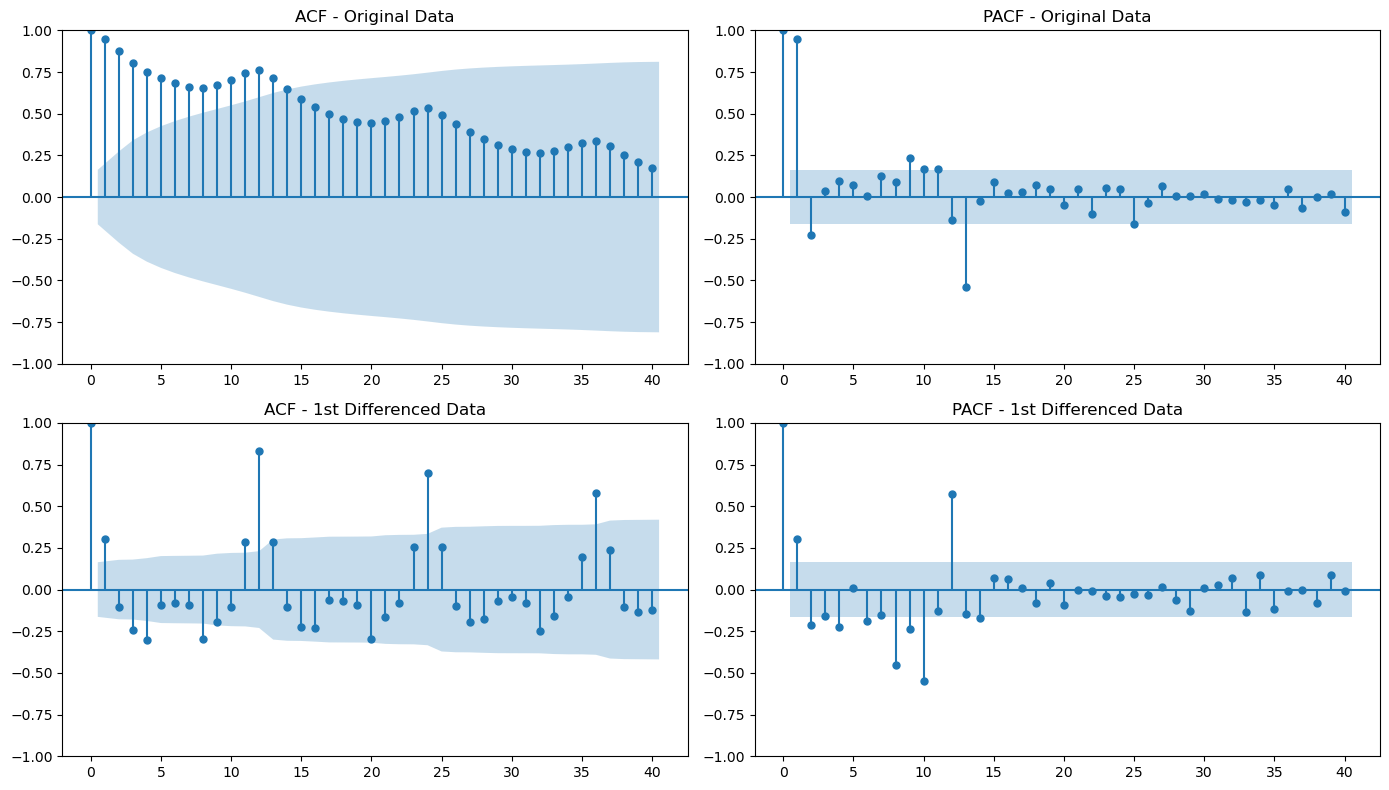

ACF se q value dekho, PACF se p value dekho
Jo lag pe line significance band ke andar aa jaye woh value choose karo


In [5]:
# ACF (Autocorrelation Function) - q parameter ke liye
# PACF (Partial Autocorrelation Function) - p parameter ke liye

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original data ke ACF/PACF
plot_acf(df['Passengers'], lags=40, ax=axes[0, 0], title='ACF - Original Data')
plot_pacf(df['Passengers'], lags=40, ax=axes[0, 1], title='PACF - Original Data')

# Differenced data ke ACF/PACF
plot_acf(df_diff, lags=40, ax=axes[1, 0], title='ACF - 1st Differenced Data')
plot_pacf(df_diff, lags=40, ax=axes[1, 1], title='PACF - 1st Differenced Data')

plt.tight_layout()
plt.show()

print("ACF se q value dekho, PACF se p value dekho")
print("Jo lag pe line significance band ke andar aa jaye woh value choose karo")

Total data points : 144
Training size     : 115
Testing size      : 29

Train period: 1949-01-01 00:00:00 to 1958-07-01 00:00:00
Test period : 1958-08-01 00:00:00 to 1960-12-01 00:00:00


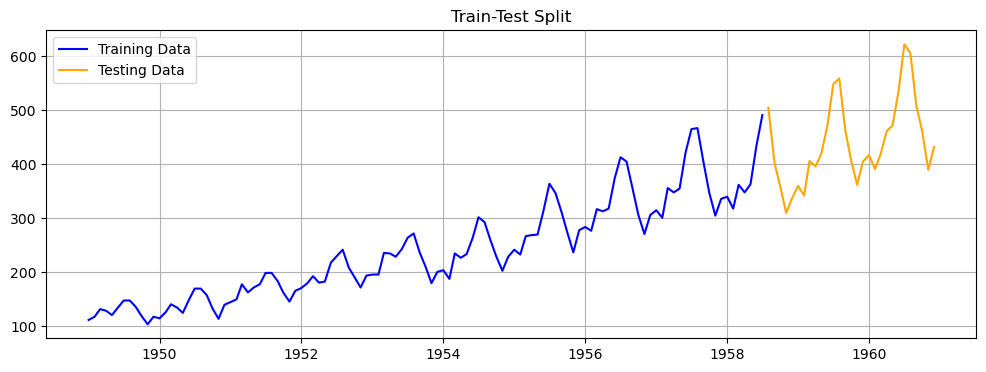

In [6]:
# Data ko train aur test mein split karo
# 80% training, 20% testing

train_size = int(len(df) * 0.8)  # 80% training ke liye

train = df['Passengers'][:train_size]  # Training data
test = df['Passengers'][train_size:]   # Testing data

print(f"Total data points : {len(df)}")
print(f"Training size     : {len(train)}")
print(f"Testing size      : {len(test)}")
print(f"\nTrain period: {train.index[0]} to {train.index[-1]}")
print(f"Test period : {test.index[0]} to {test.index[-1]}")

# Plot karo
plt.figure(figsize=(12, 4))
plt.plot(train, label='Training Data', color='blue')
plt.plot(test, label='Testing Data', color='orange')
plt.title('Train-Test Split')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# ARIMA Model fit karo
# p=5, d=1, q=0 - yeh ek common starting point hai
# Aap inhe change kar sakte ho apni ACF/PACF analysis ke basis pe

print("ARIMA Model fit ho raha hai...")

# ARIMA model define karo
arima_model = ARIMA(
    train,           # Training data
    order=(5, 1, 0)  # (p, d, q) parameters
)

# Model ko data pe fit karo
arima_result = arima_model.fit()

print("\nARIMA Model successfully fit ho gaya!")
print("\nModel Summary:")
print(arima_result.summary())

ARIMA Model fit ho raha hai...

ARIMA Model successfully fit ho gaya!

Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -524.549
Date:                Fri, 20 Feb 2026   AIC                           1061.098
Time:                        10:48:10   BIC                           1077.515
Sample:                    01-01-1949   HQIC                          1067.760
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3558      0.092      3.854      0.000       0.175       0.537
ar.L2         -0.2644      0.109     -2.422  

In [8]:
# ARIMA se Forecast karo (test data ke steps ke barabar)
arima_forecast = arima_result.forecast(steps=len(test))

# Forecast ko test index pe align karo
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

print("ARIMA Forecast values:")
print(arima_forecast)

ARIMA Forecast values:
Month
1958-08-01    500.902643
1958-09-01    489.904481
1958-10-01    466.349010
1958-11-01    449.296639
1958-12-01    449.565681
1959-01-01    456.411345
1959-02-01    463.997445
1959-03-01    468.568886
1959-04-01    467.408711
1959-05-01    464.273767
1959-06-01    461.952615
1959-07-01    460.971351
1959-08-01    461.681083
1959-09-01    462.906268
1959-10-01    463.574875
1959-11-01    463.687326
1959-12-01    463.355327
1960-01-01    462.927691
1960-02-01    462.751916
1960-03-01    462.788567
1960-04-01    462.925812
1960-05-01    463.061184
1960-06-01    463.100065
1960-07-01    463.064937
1960-08-01    463.012736
1960-09-01    462.973972
1960-10-01    462.968769
1960-11-01    462.986820
1960-12-01    463.005302
Freq: MS, dtype: float64


In [9]:
# ARIMA Accuracy Metrics calculate karo
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

print("=" * 40)
print("ARIMA Model Accuracy:")
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"MAPE : {arima_mape:.2f}%")
print("=" * 40)

ARIMA Model Accuracy:
MAE  : 67.38
RMSE : 80.66
MAPE : 16.15%


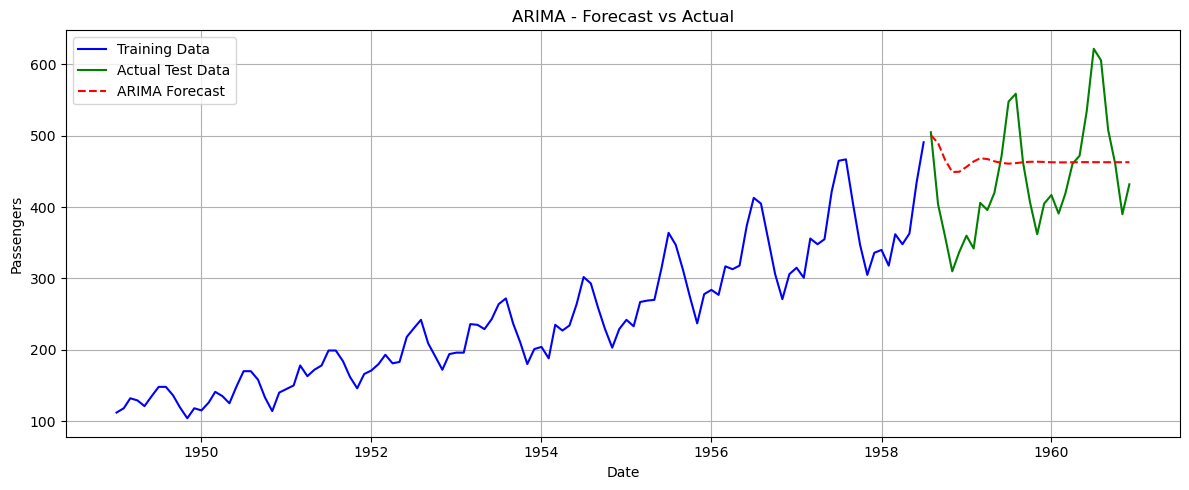

In [10]:
# ARIMA Result Plot karo
plt.figure(figsize=(12, 5))
plt.plot(train, label='Training Data', color='blue')
plt.plot(test, label='Actual Test Data', color='green')
plt.plot(arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA - Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

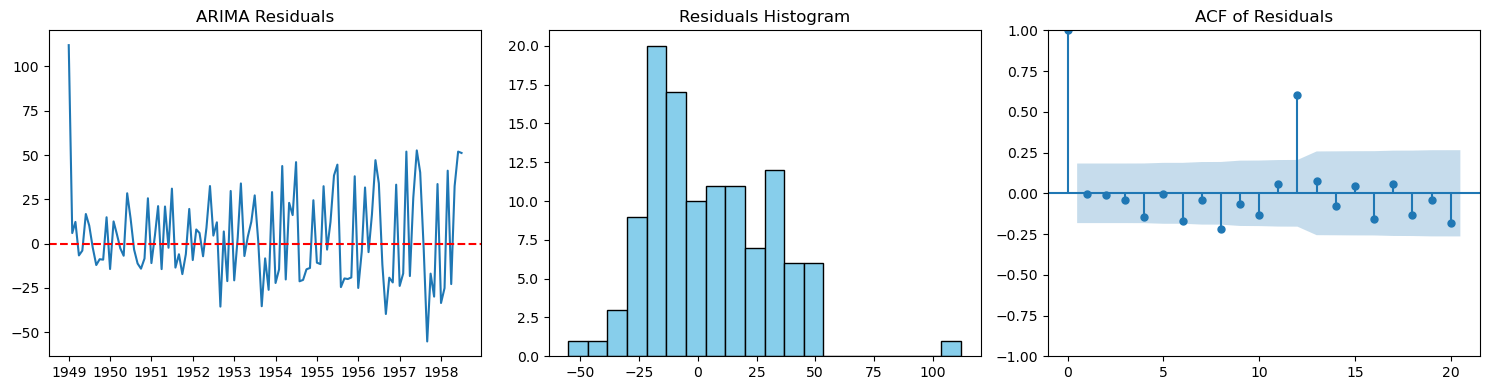

Ljung-Box Test (p > 0.05 = residuals independent hain):
      lb_stat  lb_pvalue
10  15.461751   0.116112


In [11]:
# ARIMA Residual Diagnostics
# Residuals check karo - random hone chahiye

arima_residuals = arima_result.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals plot
axes[0].plot(arima_residuals)
axes[0].set_title('ARIMA Residuals')
axes[0].axhline(y=0, color='r', linestyle='--')

# Residuals histogram
axes[1].hist(arima_residuals, bins=20, color='skyblue', edgecolor='black')
axes[1].set_title('Residuals Histogram')

# ACF of residuals
plot_acf(arima_residuals, lags=20, ax=axes[2], title='ACF of Residuals')

plt.tight_layout()
plt.show()

# Ljung-Box test (residuals mein autocorrelation hai ya nahi)
lb_test = acorr_ljungbox(arima_residuals, lags=[10], return_df=True)
print("Ljung-Box Test (p > 0.05 = residuals independent hain):")
print(lb_test)

In [12]:
# SARIMA Model fit karo
# SARIMAX function use hota hai SARIMA ke liye bhi (same class hai)
# order = (p, d, q) - non-seasonal
# seasonal_order = (P, D, Q, m) - seasonal

print("SARIMA Model fit ho raha hai...")

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),           # Non-seasonal: (p, d, q)
    seasonal_order=(1, 1, 1, 12)  # Seasonal: (P, D, Q, m=12 for monthly)
)

# Model fit karo
sarima_result = sarima_model.fit(disp=False)  # disp=False = output kam karo

print("\nSARIMA Model successfully fit ho gaya!")
print("\nModel Summary:")
print(sarima_result.summary())

SARIMA Model fit ho raha hai...

SARIMA Model successfully fit ho gaya!

Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -374.130
Date:                            Fri, 20 Feb 2026   AIC                            758.260
Time:                                    10:48:52   BIC                            771.385
Sample:                                01-01-1949   HQIC                           763.575
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6366     

In [13]:
# SARIMA Forecast karo
sarima_forecast = sarima_result.forecast(steps=len(test))

# Forecast ko test index pe align karo
sarima_forecast = pd.Series(sarima_forecast.values, index=test.index)

print("SARIMA Forecast values:")
print(sarima_forecast)

SARIMA Forecast values:
Month
1958-08-01    489.724161
1958-09-01    429.406266
1958-10-01    372.216640
1958-11-01    331.836769
1958-12-01    362.700169
1959-01-01    367.720071
1959-02-01    346.377787
1959-03-01    392.239543
1959-04-01    378.878105
1959-05-01    392.923989
1959-06-01    464.526955
1959-07-01    519.093265
1959-08-01    518.443939
1959-09-01    457.515375
1959-10-01    400.175734
1959-11-01    359.359106
1959-12-01    390.182930
1960-01-01    394.896855
1960-02-01    373.285415
1960-03-01    418.509015
1960-04-01    404.906446
1960-05-01    419.300219
1960-06-01    491.038261
1960-07-01    546.117221
1960-08-01    545.243127
1960-09-01    484.532844
1960-10-01    427.245492
1960-11-01    386.584513
1960-12-01    417.421996
Freq: MS, dtype: float64


In [14]:
# SARIMA Accuracy Metrics
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100

print("=" * 40)
print("SARIMA Model Accuracy:")
print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")
print("=" * 40)

SARIMA Model Accuracy:
MAE  : 23.56
RMSE : 30.14
MAPE : 5.05%


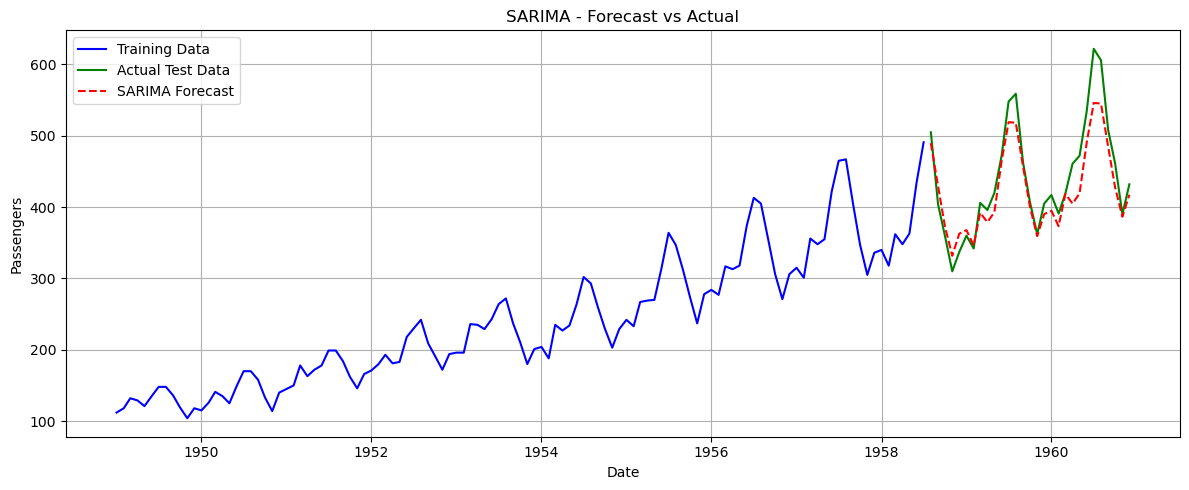

In [15]:
# SARIMA Result Plot karo
plt.figure(figsize=(12, 5))
plt.plot(train, label='Training Data', color='blue')
plt.plot(test, label='Actual Test Data', color='green')
plt.plot(sarima_forecast, label='SARIMA Forecast', color='red', linestyle='--')
plt.title('SARIMA - Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

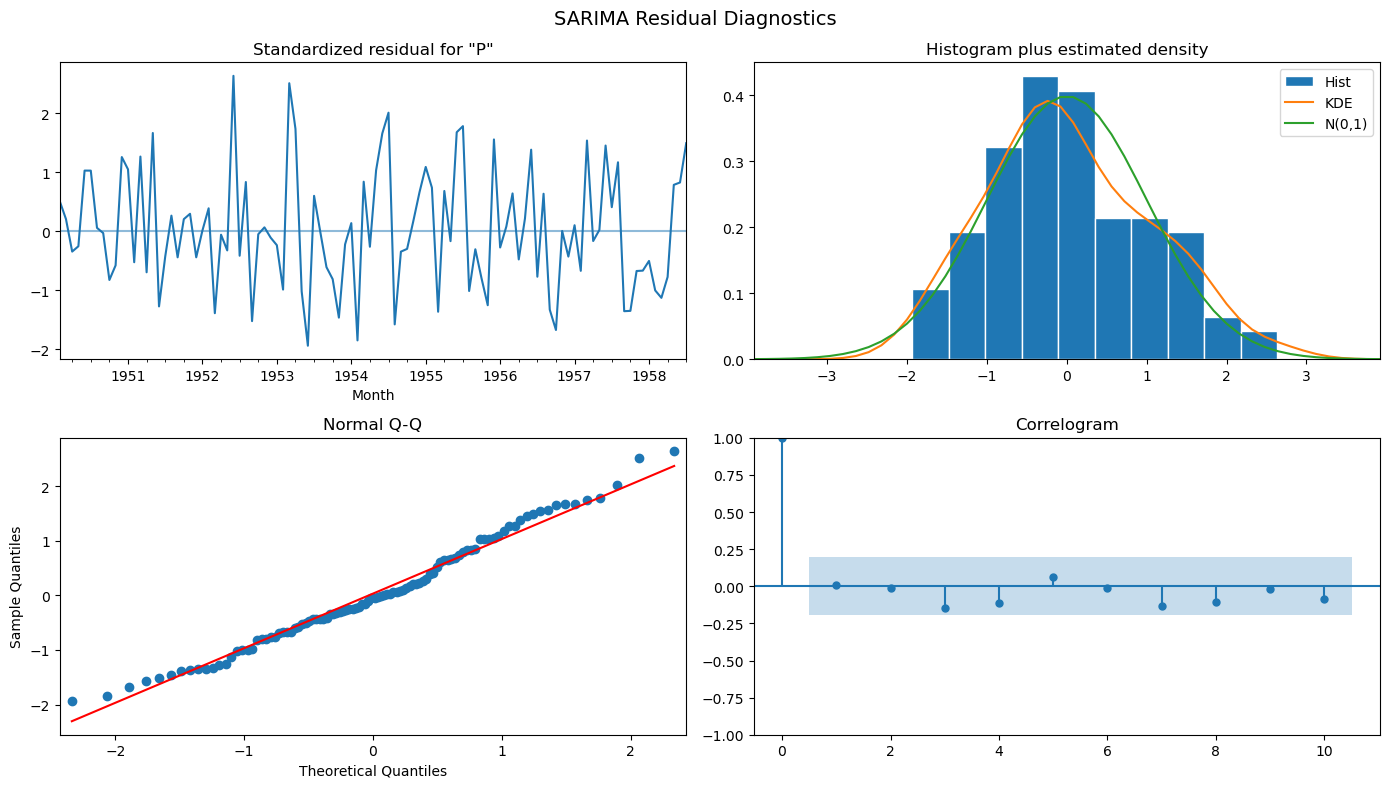

Good model ke liye:
- Residuals random hone chahiye (no pattern)
- Histogram bell-shaped hona chahiye
- Q-Q plot pe points straight line ke paas hone chahiye
- ACF mein lag 0 ke baad koi significant spike nahi hona chahiye


In [16]:
# SARIMA Residual Diagnostics (built-in plot)
# Yeh ek achha 4-panel diagnostic plot deta hai
sarima_result.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

print("Good model ke liye:")
print("- Residuals random hone chahiye (no pattern)")
print("- Histogram bell-shaped hona chahiye")
print("- Q-Q plot pe points straight line ke paas hone chahiye")
print("- ACF mein lag 0 ke baad koi significant spike nahi hona chahiye")

In [17]:
# Real data mein exogenous variable alag hoti hai
# Yahan hum ek synthetic variable banate hain demonstration ke liye
# (e.g., Fuel Price Index ya koi marketing spend)

np.random.seed(42)  # Reproducibility ke liye

# Ek fake exogenous variable banao (jaise fuel price)
# Real case mein yeh actual data hoga
exog_data = pd.Series(
    np.random.randn(len(df)) * 10 + 100,  # Random values around 100
    index=df.index,
    name='FuelPriceIndex'
)

# Train-Test split exogenous variable ke liye bhi
exog_train = exog_data[:train_size]
exog_test = exog_data[train_size:]

print("Exogenous variable (FuelPriceIndex) banaya gaya")
print(f"Train exog shape: {exog_train.shape}")
print(f"Test exog shape : {exog_test.shape}")
print("\nPehli 5 values:")
print(exog_train.head())

Exogenous variable (FuelPriceIndex) banaya gaya
Train exog shape: (115,)
Test exog shape : (29,)

Pehli 5 values:
Month
1949-01-01    104.967142
1949-02-01     98.617357
1949-03-01    106.476885
1949-04-01    115.230299
1949-05-01     97.658466
Freq: MS, Name: FuelPriceIndex, dtype: float64


In [18]:
# SARIMAX Model fit karo (SARIMA + exogenous variable)
print("SARIMAX Model fit ho raha hai...")

sarimax_model = SARIMAX(
    train,                           # Target time series (y)
    exog=exog_train,                 # Exogenous variable (X)
    order=(1, 1, 1),                 # Non-seasonal: (p, d, q)
    seasonal_order=(1, 1, 1, 12)     # Seasonal: (P, D, Q, m)
)

# Model fit karo
sarimax_result = sarimax_model.fit(disp=False)

print("\nSARIMAX Model successfully fit ho gaya!")
print("\nModel Summary:")
print(sarimax_result.summary())

SARIMAX Model fit ho raha hai...

SARIMAX Model successfully fit ho gaya!

Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -374.092
Date:                            Fri, 20 Feb 2026   AIC                            760.185
Time:                                    10:49:40   BIC                            775.934
Sample:                                01-01-1949   HQIC                           766.562
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
FuelPriceIndex  

In [19]:
# SARIMAX Forecast karo
# IMPORTANT: Forecast ke waqt future exogenous values bhi deni padti hain
sarimax_forecast = sarimax_result.forecast(
    steps=len(test),
    exog=exog_test   # Future exogenous values (test period ke liye)
)

# Forecast ko test index pe align karo
sarimax_forecast = pd.Series(sarimax_forecast.values, index=test.index)

print("SARIMAX Forecast values:")
print(sarimax_forecast)

SARIMAX Forecast values:
Month
1958-08-01    489.694686
1958-09-01    429.382888
1958-10-01    372.538349
1958-11-01    331.922952
1958-12-01    362.658101
1959-01-01    367.684056
1959-02-01    346.593081
1959-03-01    391.800287
1959-04-01    379.150748
1959-05-01    392.862548
1959-06-01    464.563841
1959-07-01    519.259251
1959-08-01    518.567822
1959-09-01    457.521891
1959-10-01    400.439107
1959-11-01    359.936056
1959-12-01    390.303705
1960-01-01    395.200202
1960-02-01    373.331173
1960-03-01    418.482205
1960-04-01    404.781550
1960-05-01    419.523115
1960-06-01    491.547378
1960-07-01    546.058781
1960-08-01    545.539221
1960-09-01    484.573583
1960-10-01    427.282087
1960-11-01    387.215697
1960-12-01    417.574994
Freq: MS, dtype: float64


In [20]:
# SARIMAX Accuracy Metrics
sarimax_mae = mean_absolute_error(test, sarimax_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(test, sarimax_forecast))
sarimax_mape = np.mean(np.abs((test - sarimax_forecast) / test)) * 100

print("=" * 40)
print("SARIMAX Model Accuracy:")
print(f"MAE  : {sarimax_mae:.2f}")
print(f"RMSE : {sarimax_rmse:.2f}")
print(f"MAPE : {sarimax_mape:.2f}%")
print("=" * 40)

SARIMAX Model Accuracy:
MAE  : 23.47
RMSE : 30.07
MAPE : 5.03%


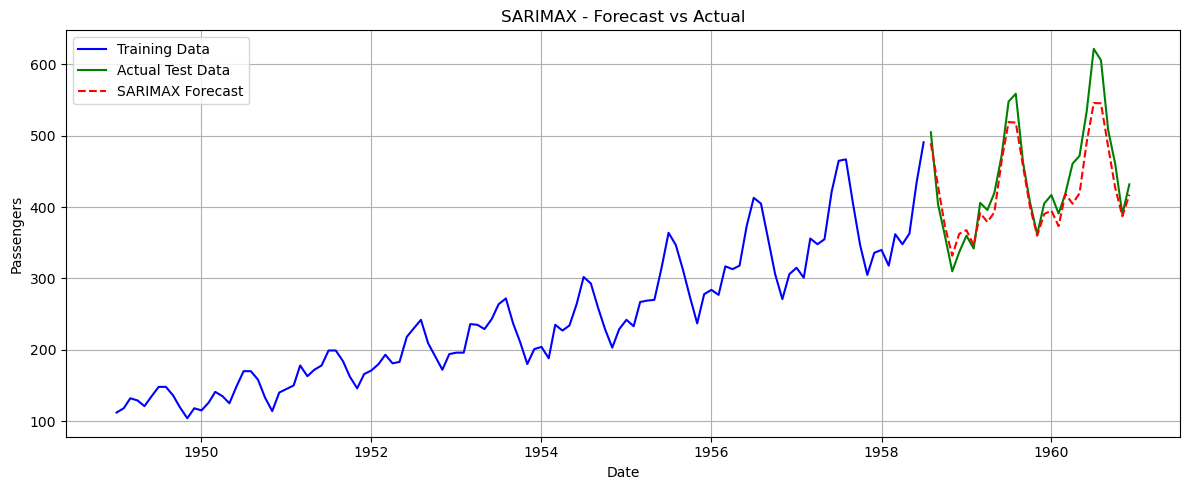

In [21]:
# SARIMAX Result Plot karo
plt.figure(figsize=(12, 5))
plt.plot(train, label='Training Data', color='blue')
plt.plot(test, label='Actual Test Data', color='green')
plt.plot(sarimax_forecast, label='SARIMAX Forecast', color='red', linestyle='--')
plt.title('SARIMAX - Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Teeno models ka comparison table banao
comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'SARIMAX'],
    'MAE': [arima_mae, sarima_mae, sarimax_mae],
    'RMSE': [arima_rmse, sarima_rmse, sarimax_rmse],
    'MAPE (%)': [arima_mape, sarima_mape, sarimax_mape]
})

print("=" * 50)
print("TEENO MODELS KA COMPARISON:")
print("=" * 50)
print(comparison_df.to_string(index=False))
print("=" * 50)
print("\nSabse kam MAE/RMSE/MAPE wala model best hai!")

TEENO MODELS KA COMPARISON:
  Model       MAE      RMSE  MAPE (%)
  ARIMA 67.383501 80.663945 16.154706
 SARIMA 23.555627 30.141897  5.052698
SARIMAX 23.467914 30.072635  5.033743

Sabse kam MAE/RMSE/MAPE wala model best hai!


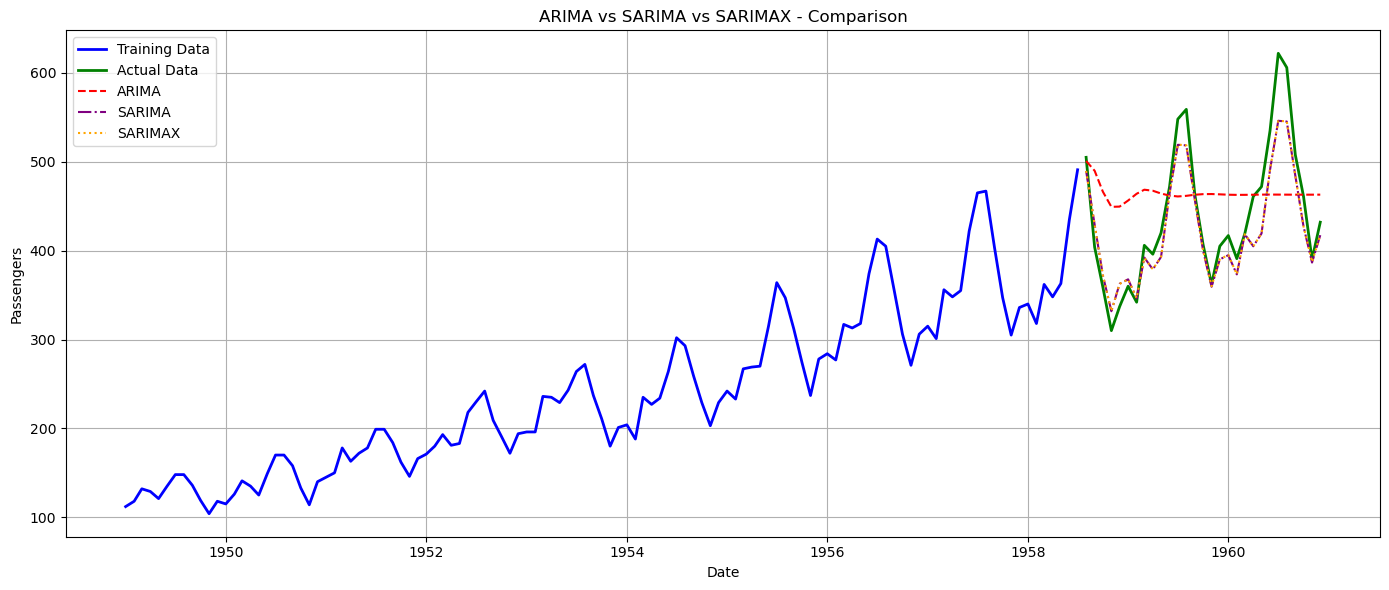

In [23]:
# Teeno forecasts ek plot mein dikhao
plt.figure(figsize=(14, 6))

plt.plot(train, label='Training Data', color='blue', linewidth=2)
plt.plot(test, label='Actual Data', color='green', linewidth=2)
plt.plot(arima_forecast, label='ARIMA', color='red', linestyle='--', linewidth=1.5)
plt.plot(sarima_forecast, label='SARIMA', color='purple', linestyle='-.', linewidth=1.5)
plt.plot(sarimax_forecast, label='SARIMAX', color='orange', linestyle=':', linewidth=1.5)

plt.title('ARIMA vs SARIMA vs SARIMAX - Comparison')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Best model (SARIMA) se future 12 months ka forecast karo
# Poore data pe SARIMA re-fit karo

print("Full data pe SARIMA re-fit ho raha hai...")

sarima_full_model = SARIMAX(
    df['Passengers'],              # Poora data
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

sarima_full_result = sarima_full_model.fit(disp=False)

# Agle 12 months ka forecast karo
future_forecast = sarima_full_result.forecast(steps=12)

print("\nAgle 12 months ka forecast:")
print(future_forecast)

Full data pe SARIMA re-fit ho raha hai...

Agle 12 months ka forecast:
1961-01-01    449.330141
1961-02-01    424.386139
1961-03-01    459.032153
1961-04-01    497.864896
1961-05-01    509.862716
1961-06-01    568.258412
1961-07-01    655.810613
1961-08-01    641.190595
1961-09-01    546.392272
1961-10-01    496.800988
1961-11-01    427.674133
1961-12-01    471.235631
Freq: MS, Name: predicted_mean, dtype: float64


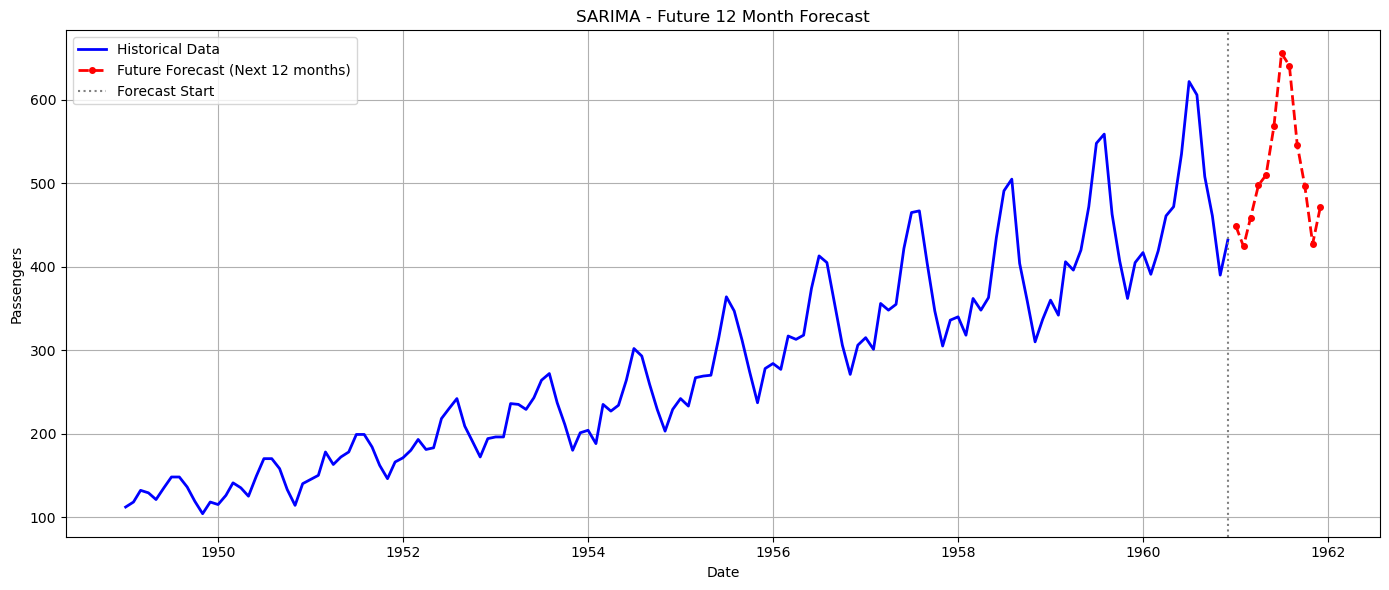


Future forecast complete!


In [25]:
# Future Forecast Plot karo
plt.figure(figsize=(14, 6))

plt.plot(df['Passengers'], label='Historical Data', color='blue', linewidth=2)
plt.plot(future_forecast, label='Future Forecast (Next 12 months)', 
         color='red', linestyle='--', linewidth=2, marker='o', markersize=4)

# Forecast aur historical data ke beech vertical line
plt.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')

plt.title('SARIMA - Future 12 Month Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nFuture forecast complete!")